# 4.3 識別モデル (Probabilistic Discriminative Models)

本ノートブックでは、クラス条件付き確率密度を経由せず、クラス事後確率 $p(\mathcal{C}_k | \mathbf{x})$ を直接パラメータ化して最尤推定する**確率的識別モデル (Probabilistic Discriminative Models)** を扱います。
非線形基底関数による分離性の獲得（**PRML Figure 4.12**）、2クラスおよび多クラスのロジスティック回帰（ソフトマックス回帰）、二次収束を達成する**反復再重み付け最小二乗法 (IRLS)** の完全実装、および累積正規分布に基づく**プロビット回帰 (PRML Figure 4.13)** と正準連結関数を理論と実践の両面から徹底的に学びます。

## 4.3.1 非線形基底関数による分離空間への写像 (PRML Figure 4.12)

元の入力空間 $\mathbf{x} = (x_1, x_2)^T$ において線形分離不可能なデータセットであっても、非線形な基底関数
$$ \boldsymbol{\phi}(\mathbf{x}) = (\phi_1(\mathbf{x}), \phi_2(\mathbf{x}))^T $$
を用いて新たな特徴空間に写像することで、**線形分離可能**に変換できる場合があります。

PRML Figure 4.12 では、2つのガウス基底関数 $\phi_1(\mathbf{x}) = \exp(-\|\mathbf{x} - \boldsymbol{\mu}_1\|^2 / 2s^2)$ と $\phi_2(\mathbf{x}) = \exp(-\|\mathbf{x} - \boldsymbol{\mu}_2\|^2 / 2s^2)$ を用いて、元の入力空間の同心円状あるいは複雑に入り組んだクラスが特徴空間上で直線で分離できるようになる様子を示しています。

Plot saved to: result/fig4_12_feature_space_mapping.png


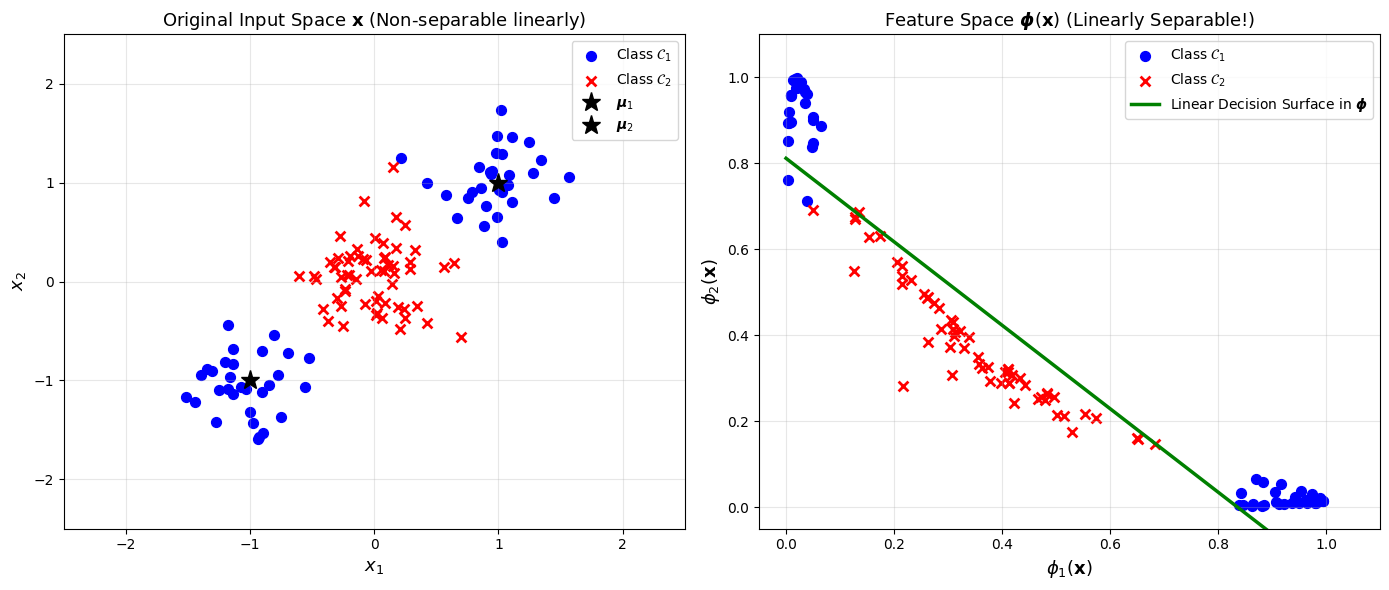

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
from common.plot_utils import save_plot, setup_style
from common.classification_utils import LogisticRegression, plot_decision_boundary_2d, sigmoid
setup_style()

np.random.seed(42)

# PRML Figure 4.12 の再現: 元の空間 (非線形) と 特徴空間 (線形分離可能)
N_each = 60

# クラス 1: 2つの別々のクラスタ
C1_a = np.random.randn(N_each//2, 2) * 0.3 + np.array([-1.0, -1.0])
C1_b = np.random.randn(N_each//2, 2) * 0.3 + np.array([1.0, 1.0])
X_c1 = np.vstack([C1_a, C1_b])

# クラス 2: 中央のクラスタ
X_c2 = np.random.randn(N_each, 2) * 0.3 + np.array([0.0, 0.0])

X_orig = np.vstack([X_c1, X_c2])
y_labels = np.array([0]*N_each + [1]*N_each)

# 2つのガウス基底の中心
mu1 = np.array([-1.0, -1.0])
mu2 = np.array([1.0, 1.0])
scale_sq = 1.0

phi1 = np.exp(-np.sum((X_orig - mu1)**2, axis=1) / (2 * scale_sq))
phi2 = np.exp(-np.sum((X_orig - mu2)**2, axis=1) / (2 * scale_sq))
Phi_feat = np.column_stack([phi1, phi2])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 左: 元の入力空間 (x1, x2)
axes[0].scatter(X_c1[:, 0], X_c1[:, 1], c='b', marker='o', s=50, label='Class $\mathcal{C}_1$')
axes[0].scatter(X_c2[:, 0], X_c2[:, 1], c='r', marker='x', s=50, lw=2, label='Class $\mathcal{C}_2$')
axes[0].plot(mu1[0], mu1[1], 'k*', markersize=14, label=r'$\boldsymbol{\mu}_1$')
axes[0].plot(mu2[0], mu2[1], 'k*', markersize=14, label=r'$\boldsymbol{\mu}_2$')
axes[0].set_title('Original Input Space $\mathbf{x}$ (Non-separable linearly)', fontsize=13)
axes[0].set_xlabel('$x_1$', fontsize=13); axes[0].set_ylabel('$x_2$', fontsize=13)
axes[0].set_xlim(-2.5, 2.5); axes[0].set_ylim(-2.5, 2.5)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 右: 特徴空間 (phi1, phi2)
axes[1].scatter(Phi_feat[:N_each, 0], Phi_feat[:N_each, 1], c='b', marker='o', s=50, label='Class $\mathcal{C}_1$')
axes[1].scatter(Phi_feat[N_each:, 0], Phi_feat[N_each:, 1], c='r', marker='x', s=50, lw=2, label='Class $\mathcal{C}_2$')

# 特徴空間でのロジスティック回帰
Phi_with_bias = np.column_stack([np.ones(len(Phi_feat)), Phi_feat])
lr = LogisticRegression().fit(Phi_with_bias, y_labels)
w_feat = lr.w

p1_grid = np.linspace(0, 1.1, 100)
p2_bound = -(w_feat[0] + w_feat[1] * p1_grid) / (w_feat[2] + 1e-10)
axes[1].plot(p1_grid, p2_bound, 'g-', lw=2.5, label=r'Linear Decision Surface in $\boldsymbol{\phi}$')
axes[1].set_title(r'Feature Space $\boldsymbol{\phi}(\mathbf{x})$ (Linearly Separable!)', fontsize=13)
axes[1].set_xlabel(r'$\phi_1(\mathbf{x})$', fontsize=13); axes[1].set_ylabel(r'$\phi_2(\mathbf{x})$', fontsize=13)
axes[1].set_xlim(-0.05, 1.1); axes[1].set_ylim(-0.05, 1.1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_plot(fig, 'result', 'fig4_12_feature_space_mapping.png')
plt.show()

## 4.3.2 & 4.3.3 ロジスティック回帰と反復再重み付け最小二乗法 (IRLS)

ロジスティック回帰モデルでは、特徴ベクトル $\boldsymbol{\phi}$ に対するクラス $\mathcal{C}_1$ の事後確率をシグモイド関数でモデル化します：
$$ p(\mathcal{C}_1 | \boldsymbol{\phi}) = y(\boldsymbol{\phi}) = \sigma(\mathbf{w}^T \boldsymbol{\phi}) $$
ラベル $t_n \in \{0, 1\}$ の独立同分布データセットに対する負の対数尤度関数は**交差エントロピー誤差**となります：
$$ E(\mathbf{w}) = -\ln p(\mathbf{t} | \mathbf{w}) = -\sum_{n=1}^N \left\{ t_n \ln y_n + (1 - t_n) \ln (1 - y_n) \right\} $$

### 勾配とヘッセ行列
シグモイドの微分公式 $\frac{d\sigma}{da} = \sigma(1 - \sigma) = y(1 - y)$ より、誤差関数の勾配は：
$$ \nabla E(\mathbf{w}) = \sum_{n=1}^N (y_n - t_n) \boldsymbol{\phi}_n = \mathbf{\Phi}^T (\mathbf{y} - \mathbf{t}) $$
この式は、第3章の線形回帰の最小二乗誤差の勾配と**全く同一の美しい形式**をとっています！

さらに2階微分をとるとヘッセ行列が得られます：
$$ \mathbf{H} = \nabla \nabla E(\mathbf{w}) = \sum_{n=1}^N y_n (1 - y_n) \boldsymbol{\phi}_n \boldsymbol{\phi}_n^T = \mathbf{\Phi}^T \mathbf{R} \mathbf{\Phi} $$
ここで $\mathbf{R}$ は対角成分 $R_{nn} = y_n (1 - y_n) > 0$ を持つ対角重み行列です。
任意のベクトル $\mathbf{u} \neq \mathbf{0}$ に対し
$$ \mathbf{u}^T \mathbf{H} \mathbf{u} = (\mathbf{\Phi}\mathbf{u})^T \mathbf{R} (\mathbf{\Phi}\mathbf{u}) = \sum_n R_{nn} (\boldsymbol{\phi}_n^T \mathbf{u})^2 \ge 0 $$
となるため、$\mathbf{H}$ は**常に半正定値（正定値）**であり、誤差関数 $E(\mathbf{w})$ は**大域的最小値を持つ狭義の凸関数**であることが保証されます。

### ニュートン・ラフソン法による IRLS 更新
$$ \mathbf{w}^{(\tau+1)} = \mathbf{w}^{(\tau)} - \mathbf{H}^{-1} \nabla E = (\mathbf{\Phi}^T \mathbf{R} \mathbf{\Phi})^{-1} \mathbf{\Phi}^T \mathbf{R} \mathbf{z} $$
ここで有効目標値ベクトル $\mathbf{z}$ は
$$ \mathbf{z} = \mathbf{\Phi} \mathbf{w}^{(\tau)} - \mathbf{R}^{-1} (\mathbf{y} - \mathbf{t}) $$
と表されます。各反復において重み行列 $\mathbf{R}$ を再計算しながら重み付き最小二乗を解くため、このアルゴリズムは**反復再重み付け最小二乗法 (Iterative Reweighted Least Squares: IRLS)** と呼ばれます。

Plot saved to: result/fig4_irls_convergence.png


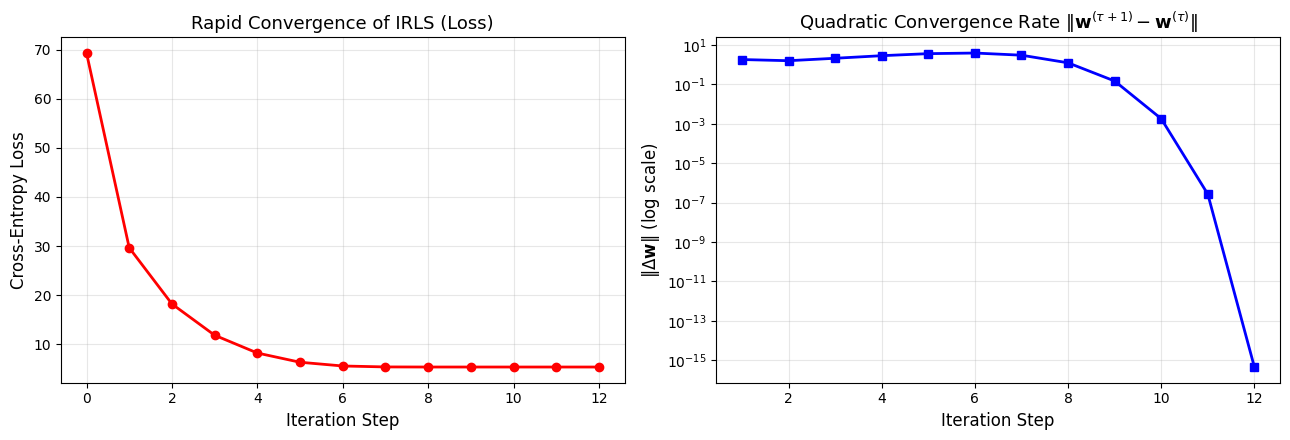

In [2]:
# IRLS アルゴリズムの収束速度 (ニュートン・ラフソン法の二次収束)
np.random.seed(42)
N_pts = 100
X_demo = np.random.randn(N_pts, 2)
t_demo = (X_demo[:, 0] * 1.5 - X_demo[:, 1] * 0.8 + np.random.randn(N_pts)*0.2 > 0).astype(int)
Phi_demo = np.column_stack([np.ones(N_pts), X_demo])

lr_irls = LogisticRegression(alpha=1e-4, max_iter=20, tol=1e-8)
lr_irls.fit(Phi_demo, t_demo)

# 各ステップでの誤差と更新量の推移
losses = []
delta_norms = []
for i in range(len(lr_irls.history)):
    w_i = lr_irls.history[i]
    y_i = sigmoid(Phi_demo @ w_i)
    loss = -np.sum(t_demo * np.log(y_i + 1e-12) + (1 - t_demo) * np.log(1 - y_i + 1e-12))
    losses.append(loss)
    if i > 0:
        delta_norms.append(np.linalg.norm(lr_irls.history[i] - lr_irls.history[i-1]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(range(len(losses)), losses, 'ro-', lw=2)
axes[0].set_xlabel('Iteration Step')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Rapid Convergence of IRLS (Loss)', fontsize=13)
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(range(1, len(losses)), delta_norms, 'bs-', lw=2)
axes[1].set_xlabel('Iteration Step')
axes[1].set_ylabel(r'$\|\Delta \mathbf{w}\|$ (log scale)')
axes[1].set_title(r'Quadratic Convergence Rate $\|\mathbf{w}^{(\tau+1)} - \mathbf{w}^{(\tau)}\|$', fontsize=13)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_plot(fig, 'result', 'fig4_irls_convergence.png')
plt.show()

## 4.3.5 プロビット回帰 (Probit Regression, PRML Figure 4.13)

活性化関数 $f(a)$ としてロジスティックシグモイド $\sigma(a)$ の代わりに、標準正規分布の累積分布関数（プロビット関数）
$$ \Phi(a) = \int_{-\infty}^a \mathcal{N}(\theta | 0, 1) d\theta = \frac{1}{2} \left[ 1 + \mathrm{erf}\left(\frac{a}{\sqrt{2}}\right) \right] $$
を用いる一般化線形モデルを**プロビット回帰 (Probit Regression)** と呼びます。

### シグモイド関数との比較 (PRML Figure 4.13)
プロビット関数 $\Phi(a)$ の分散をシグモイド関数 $\sigma(a)$ の分散 $\pi^2 / 3$ に揃えるため、引数を $\sqrt{\pi / 8} a$ とスケール調整すると、両者は中央付近で極めて類似した形状を示します。
しかし、裾野（tail）の振る舞いには決定的な違いがあります：
- プロビット関数: 正規分布の減衰に従い、$\exp(-a^2 / 2)$ で**極めて急速に減衰**する。
- ロジスティックシグモイド: $\exp(-a)$ で**緩やかに指数減衰**する。
このため、外れ値が存在する場合、プロビット回帰はシグモイドロジスティック回帰よりも外れ値に対して敏感（影響を受けやすい）になります。

Plot saved to: result/fig4_13_probit_vs_sigmoid.png


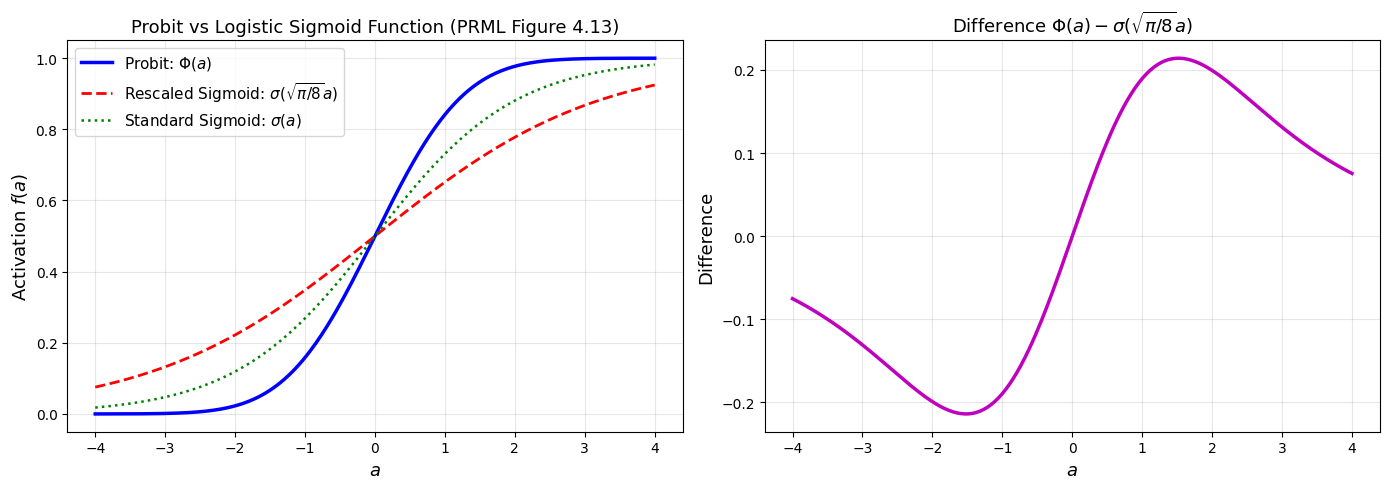

In [3]:
# PRML Figure 4.13 の再現: プロビット関数とスケール調整シグモイドの比較
from scipy.special import erf

a_vals = np.linspace(-4, 4, 300)

# プロビット関数 Phi(a)
probit = 0.5 * (1.0 + erf(a_vals / np.sqrt(2.0)))

# スケール調整したロジスティックシグモイド: sigma(sqrt(pi / 8) * a)
scaled_sigmoid = sigmoid(np.sqrt(np.pi / 8.0) * a_vals)

# 通常のシグモイド
standard_sigmoid = sigmoid(a_vals)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (1) 全体像の比較
axes[0].plot(a_vals, probit, 'b-', lw=2.5, label=r'Probit: $\Phi(a)$')
axes[0].plot(a_vals, scaled_sigmoid, 'r--', lw=2.0, label=r'Rescaled Sigmoid: $\sigma(\sqrt{\pi/8} a)$')
axes[0].plot(a_vals, standard_sigmoid, 'g:', lw=1.8, label=r'Standard Sigmoid: $\sigma(a)$')
axes[0].set_title('Probit vs Logistic Sigmoid Function (PRML Figure 4.13)', fontsize=13)
axes[0].set_xlabel('$a$', fontsize=13); axes[0].set_ylabel('Activation $f(a)$', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# (2) 差分の詳細 (裾野での振る舞いの違い)
axes[1].plot(a_vals, probit - scaled_sigmoid, 'm-', lw=2.5)
axes[1].set_title(r'Difference $\Phi(a) - \sigma(\sqrt{\pi/8} a)$', fontsize=13)
axes[1].set_xlabel('$a$', fontsize=13); axes[1].set_ylabel('Difference', fontsize=13)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_plot(fig, 'result', 'fig4_13_probit_vs_sigmoid.png')
plt.show()